In [2]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from sklearn.metrics import balanced_accuracy_score

### Реализация модели Ванильного градиентного спуска для задачи регрессии

<h3>Постановка задачи:</h3>

Algoritm: $$a(w, x)= \langle x, w \rangle = \sum_{j=1}^n w_{j} f_{j}(x)  $$

Loss-function: $$L(a, y) = (a(w, x) - y)^2$$

Empirical Risk: $$Q(a, y) = \sum_{i=1}^l L(a, y) \to \min_{w \in \mathbb{R}^n} $$

<h3>Подготовка синтетических данных:</h3>

Зависимость: линейная + шум<br>
Выборка: $l = 100$<br>
Число признаков: $n = 3$<br>
Истинные веса $w = (10, 2, 5, 0.3)$

Steepest Descent: $$Q(w^{(t)} - h \, \nabla Q(w^{(t)})) = Q(w^{(t+1)}) \to \min_{h}$$

Vanilla Gradient Descent: $$w^{(t+1)} = w^{(t)} - h \, \nabla Q(w^{(t)}) $$

In [ ]:
# Создадим класс для вычисления ванильного градиента для n-переменных задачи регрессии:
class RegVanillaGD():
    
    def __init__(self):
        self.w_old = None
        self.list_of_loss = []
        self.delta_w = 1
        
    # 1. Настройка конфигурации
    def configure(self, w_start, t=0, tolerance=1e-06, limit=100):
        self.t = t
        self.tolerance = tolerance
        self.limit = limit
        self.list_of_loss = []
        
        if isinstance(w_start, list):
            self.w_old = np.array([w_start.copy()]).T
            
        else:
            raise ValueError("Параметр w_start типа list")
        
        return self
    
    # Функция для скорейшего градиентного спуска
    def empirical_risk_at_step(self, h, w, X, y, grad):
        
        w_next = w - h * grad
        pred = X @ w_next
        
        return np.mean((pred - y) ** 2)
    
    # 3. Оптимизация весов
    def optimizer(self, X, y):
        self.delta_w = 1
        l = X.shape[0]
        n = X.shape[1]
        n_sympy = n - 1
        
        # Создаем символьные веса и признаки, ответы:
        w_sym = sp.IndexedBase('w')
        x_sym = sp.IndexedBase('x')
        y_sym = sp.Symbol('y')

        # Определяем индексы для суммирования:
        j = sp.symbols('j', cls=sp.Idx)

        # Модель регрессии:
        a = sp.Sum(w_sym[j] * x_sym[j], (j, 0, n_sympy))

        # Лос-функция:
        L = (a - y_sym) ** 2
        L_func = sp.lambdify((w_sym, x_sym, y_sym), L, 'numpy')
        
        # Найдем градиент:
        grad_L = [sp.diff(L, w_sym[j]) for j in range(n)]
        grad_L = sp.lambdify((w_sym, x_sym, y_sym), grad_L, 'numpy')
        
        while self.delta_w > self.tolerance and self.t < self.limit:

            # Рассчитаем эмпирический риск:
            Q = np.mean(
                np.array([L_func(self.w_old, X[i], y[i]) for i in range(l)])
                )
            self.list_of_loss.append(Q)

            # 2. Градиент эмпирического риска для w_old:
            grad_Q = np.mean(
                np.array([grad_L(self.w_old, X[i], y[i]) for i in range(l)]), axis=0
                ).reshape(-1, 1)

            # 3. Выберем шаг методом скорейшего градиентного спуска
            res = minimize_scalar(self.empirical_risk_at_step, args=(self.w_old, X, y, grad_Q), bounds=(0, 1), method='bounded')
            h = res.x
            
            # 4. Шаг градиентного спуска:
            w_new = self.w_old - h * grad_Q

            # 5. Критерий остановки:
            self.delta_w = np.linalg.norm(self.w_old - w_new)
            
            # Перезапись для следующего шага
            self.t += 1
            self.w_old = w_new
        
        self.params = w_new
        self.pred = X @ w_new
        
   
    # Оценка точности прогноза
    @staticmethod
    def r2(y_true, y_pred):
        
        return 1 - np.sum((y_pred - y_true) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)
    
    @staticmethod
    def mean_squared_error(y_true, y_pred):
        
        return np.mean((y_pred - y_true) ** 2)
    

        

In [4]:
np.random.seed(42)

l = 1000
n = 3

# Создадим матрицу факторов
X1 = np.linspace(0, 30, l)
X2 = np.random.uniform(0, 30, l)
X3 = np.random.normal(15, 5, l)

X = np.vstack([np.ones([1,l]), X1, X2, X3]).T

# Зададим истинные веса
w_true = np.array([[10, 2, 5, 0.3]]).T

# Определим зависимость (ответы y)
noise = 10 * np.random.randn(l).reshape([l, 1])
y = X @ w_true + noise

In [5]:
# Создадим модель
model = RegVanillaGD()

# Настроим модель
model.configure(w_start=[0, 0, 0, 0])

# Найдем оптимальные веса
model.optimizer(X=X, y=y)
w_opt = model.params

# Оценка точности прогноза
y_pred = model.pred
R2 = model.r2(y_true=y, y_pred=y_pred)
MSE = model.mean_squared_error(y_true=y, y_pred=y_pred)

# Вывод результатов

print('Веса успешно подобраны:', '-'*25, sep='\n')
for n, w in enumerate(model.params):
    print(f'w{n} = {round(w[0], 4)}')

print('\nОценка точности прогноза:', '-'*25, f'R2: {R2}', f'RMSE: {np.sqrt(MSE)}', sep='\n')


Веса успешно подобраны:
-------------------------
w0 = 0.3514
w1 = 2.1547
w2 = 5.1779
w3 = 0.5801

Оценка точности прогноза:
-------------------------
R2: 0.9585469642867751
RMSE: 9.862156415461733


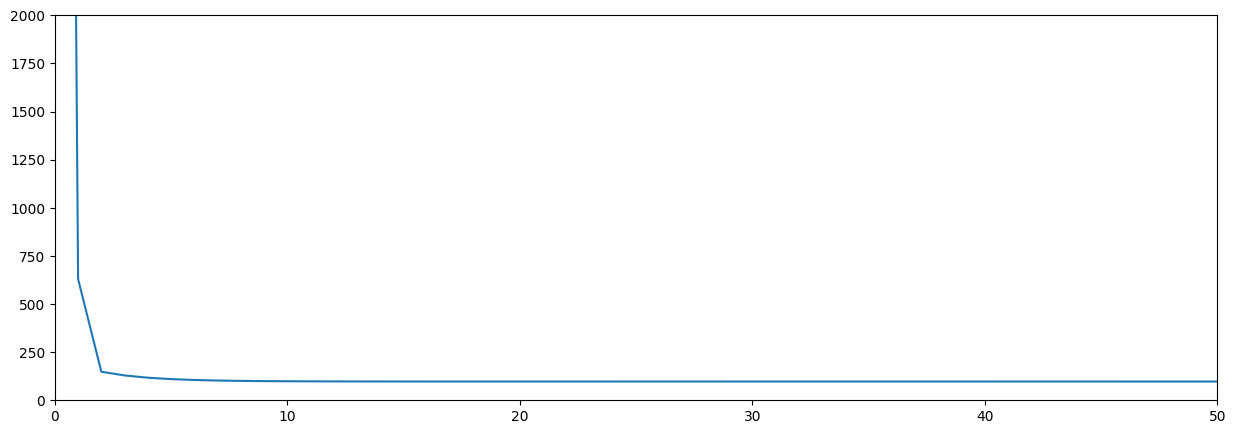

In [6]:
# Изменение эмпирического риска от числа итераций
plt.figure(figsize=(15, 5))

plt.plot(model.list_of_loss)

plt.ylim((0, 2000))
plt.xlim((0, 50))
plt.show()


### Задача регрессии при n=10

In [7]:
# Проверим работу при n=10
l = 1000
n = 10

Xn = np.random.randn(l, n)
X = np.hstack([np.ones((l, 1)), Xn])

# Зададим истинные веса
w_true = np.array([[10, 2, 5, 0.3, 0.1, 0.05, 0.8, 9, 20, 2, 15]]).T

# Определим зависимость (ответы y)
noise = 10 * np.random.randn(l).reshape([l, 1])
y = X @ w_true + noise


In [8]:
# Создадим модель
model = RegVanillaGD()

# Настроим модель
w_start = list(np.zeros(n+1))
model.configure(w_start=w_start)

# Найдем оптимальные веса
model.optimizer(X=X, y=y)
w_opt = model.params

# Оценка точности прогноза
y_pred = model.pred
R2 = model.r2(y_true=y, y_pred=y_pred)
MSE = model.mean_squared_error(y_true=y, y_pred=y_pred)

# Вывод результатов

print('Веса успешно подобраны:', '-'*25, sep='\n')
for n, w in enumerate(model.params):
    print(f'w{n} = {round(w[0], 4)}')

print('\nОценка точности прогноза:', '-'*25, f'R2: {R2}', f'RMSE: {np.sqrt(MSE)}', sep='\n')

Веса успешно подобраны:
-------------------------
w0 = 10.3417
w1 = 1.2635
w2 = 4.9906
w3 = 0.4264
w4 = 0.5909
w5 = 0.226
w6 = 1.0556
w7 = 8.7625
w8 = 19.8785
w9 = 1.4345
w10 = 15.1102

Оценка точности прогноза:
-------------------------
R2: 0.8729711285829307
RMSE: 10.1926909756219


### Реализация модели Ванильного градиентного спуска для задачи классификации

<h3>Постановка задачи:</h3>

Algoritm: $$a(w, x)= sign\langle x, w \rangle = sign\sum_{j=1}^n w_{j} f_{j}(x)  $$

Loss-function (Логарифмическая аппроксимация, сокр. LR-аппроксимация):
$$
L(a, y) = [sign\langle x, w \rangle y < 0] = [\langle x, w \rangle \, y < 0] \leq L(M)
$$

$$
L(M) = \log_{2}(1 + e^{-M})
$$



Empirical Risk: $$Q(a, y) = \sum_{i=1}^l L(\langle x_{i}, w \rangle \, y_{i}) \to \min_{w \in \mathbb{R}^n} $$

Steepest Descent: $$Q(w^{(t)} - h \, \nabla Q(w^{(t)})) = Q(w^{(t+1)}) \to \min_{h}$$


Vanilla Gradient Descent: $$w^{(t+1)} = w^{(t)} - h \, \nabla Q(w^{(t)}) $$

In [ ]:
# Создадим класс для вычисления ванильного градиента для n-переменных задачи бинарной классификации:
class BclVanillaGD():
    
    def __init__(self):
        self.w_old = None
        self.list_of_loss = []
        self.delta_w = 1
        
    # 1. Настройка конфигурации
    def configure(self, w_start, t=0, tolerance=1e-06, limit=100):
        self.t = t
        self.tolerance = tolerance
        self.limit = limit
        self.list_of_loss = []
        
        if isinstance(w_start, list):
            self.w_old = np.array([w_start.copy()]).T
            
        else:
            raise ValueError("Параметр w_start типа list")
        
        return self
    
    # Функция для скорейшего градиентного спуска
    def empirical_risk_at_step(self, h, w, X, y, grad):
        
        w_next = w - h * grad
        pred = X @ w_next
        
        return np.mean((pred - y) ** 2)
    
    # 3. Оптимизация весов
    def optimizer(self, X, y, h_opt=False):
        self.delta_w = 1
        l = X.shape[0]
        n = X.shape[1]
        n_sympy = n - 1
        
        # Создаем символьные веса и признаки, ответы:
        w_sym = sp.IndexedBase('w')
        x_sym = sp.IndexedBase('x')
        y_sym = sp.Symbol('y')

        # Определяем индексы для суммирования:
        j = sp.symbols('j', cls=sp.Idx)

        # Модель классификации:
        a = sp.Sum(w_sym[j] * x_sym[j], (j, 0, n_sympy))

        # Лос-функция:
        M = a * y_sym
        L = sp.log(1 + sp.exp(-M), 2)
        L_func = sp.lambdify((w_sym, x_sym, y_sym), L, 'numpy')
        
        # Найдем градиент:
        grad_L = [sp.diff(L, w_sym[j]) for j in range(n)]
        grad_L = sp.lambdify((w_sym, x_sym, y_sym), grad_L, 'numpy')
        
        while self.delta_w > self.tolerance and self.t < self.limit:

            # Рассчитаем эмпирический риск:
            Q = np.mean(
                np.array([L_func(self.w_old, X[i], y[i]) for i in range(l)])
                )
            self.list_of_loss.append(Q)

            # 2. Градиент эмпирического риска для w_old:
            grad_Q = np.mean(
                np.array([grad_L(self.w_old, X[i], y[i]) for i in range(l)]), axis=0
                ).reshape(-1, 1)

            # 3. Выберем шаг методом скорейшего градиентного спуска
            
            if h_opt:
                res = minimize_scalar(self.empirical_risk_at_step, args=(self.w_old, X, y, grad_Q), bounds=(0, 1), method='bounded')
                h = res.x
                
            else:
                h = 1 / np.sqrt(self.t+1)
            
            
            # 4. Шаг градиентного спуска:
            w_new = self.w_old - h * grad_Q

            # 5. Критерий остановки:
            self.delta_w = np.linalg.norm(self.w_old - w_new)
            
            # Перезапись для следующего шага
            self.t += 1
            self.w_old = w_new
        
        self.params = w_new
        self.pred = np.ones(l).reshape(-1, 1)
        self.pred[X @ self.params < 0] = -1
        
   
    # Оценка точности прогноза
    @staticmethod
    def accuracy_score(y_true, y_pred):
        
        return np.mean((y_true == y_pred).flatten())
    
    

        

In [10]:
np.random.seed(42)

l = 1000
n = 2

X1 = np.random.normal(0, 1, l)
X2 = np.random.normal(0, 3, l)

X = np.vstack([np.ones([1,l]), X1, X2]).T

w_true = np.random.randn(3).reshape(-1, 1)
y = np.ones(l).reshape(-1, 1)
y[X @ w_true < 0] = -1

In [11]:
# Создадим модель
model = BclVanillaGD()

# Настроим модель
w_start = list(np.zeros(n+1))
model.configure(w_start=w_start, limit=100)

# Найдем оптимальные веса
model.optimizer(X=X, y=y)
w_opt = model.params

# Оценка точности прогноза
y_pred = model.pred
accuracy_score = model.accuracy_score(y_true=y, y_pred=y_pred)

# Вывод результатов

print('Веса успешно подобраны:', '-'*25, sep='\n')
for n, w in enumerate(model.params):
    print(f'w{n} = {round(w[0], 4)}')

print('\nОценка точности прогноза:', '-'*25, f'accuracy_score: {accuracy_score}', sep='\n')

Веса успешно подобраны:
-------------------------
w0 = -1.5212
w1 = -0.2046
w2 = -2.1887

Оценка точности прогноза:
-------------------------
accuracy_score: 0.985


In [12]:
# Также рассчитаем сбалансированную оценку точности
balanced_accuracy_score(y, y_pred)

np.float64(0.9883900928792569)

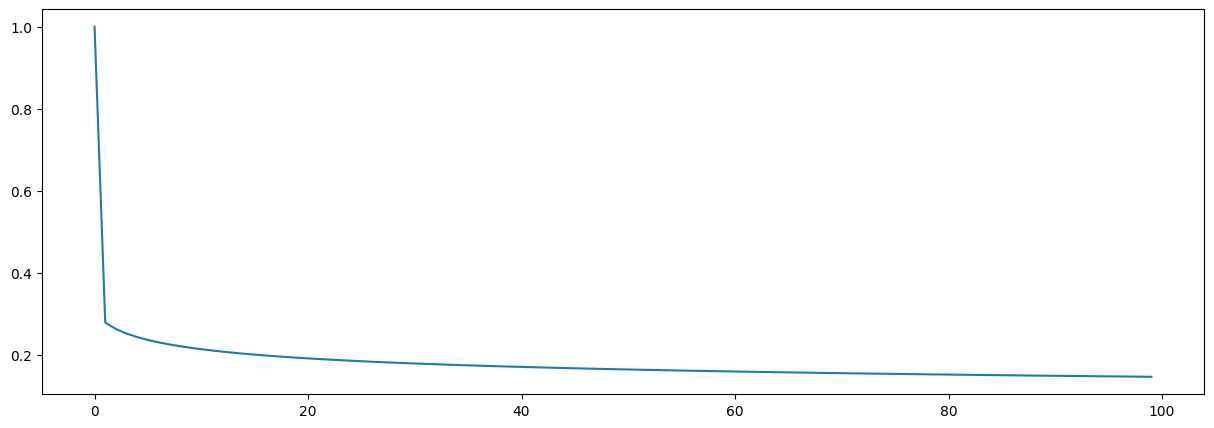

In [13]:
# Изменение эмпирического риска от числа итераций
plt.figure(figsize=(15, 5))
plt.plot(model.list_of_loss)

plt.show()

### Задача бинарной классификации при n=10

In [14]:
# Проверим работу при n=10
l = 1000
n = 10

Xn = np.random.randn(l, n)
X = np.hstack([np.ones((l, 1)), Xn])

# Зададим истинные веса
w_true = np.random.randn(n+1).reshape(-1, 1)

# Зададим ответы
y = np.ones(l).reshape(-1, 1)
y[X @ w_true < 0] = -1


In [15]:
# Создадим модель
model = BclVanillaGD()

# Настроим модель
w_start = list(np.zeros(n+1))
model.configure(w_start=w_start, limit=100)

# Найдем оптимальные веса
model.optimizer(X=X, y=y, h_opt=True)
w_opt = model.params

# Оценка точности прогноза
y_pred = model.pred
accuracy_score = model.accuracy_score(y_true=y, y_pred=y_pred)

# Вывод результатов

print('Веса успешно подобраны:', '-'*25, sep='\n')
for n, w in enumerate(model.params):
    print(f'w{n} = {round(w[0], 4)}')

print('\nОценка точности прогноза:', '-'*25, f'accuracy_score: {accuracy_score}', sep='\n')

Веса успешно подобраны:
-------------------------
w0 = -0.0545
w1 = -0.0214
w2 = 0.077
w3 = 0.3305
w4 = 0.0258
w5 = -0.1589
w6 = -0.2264
w7 = -0.2819
w8 = 0.3551
w9 = -0.2416
w10 = 0.3889

Оценка точности прогноза:
-------------------------
accuracy_score: 0.959


In [16]:
# Также рассчитаем сбалансированную оценку точности
balanced_accuracy_score(y, y_pred)

np.float64(0.9581894821356884)